In [3]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

In [4]:
def gen_noise(t, sd, bw, dt):
    t_coarse = np.arange(0, t, 1/bw)
    coarse_noise = np.random.normal(0, sd, size=len(t_coarse))
    wgn = np.interp(np.arange(0,t,dt), t_coarse, coarse_noise, left=coarse_noise[0], right=coarse_noise[-1])
    return wgn

def sim_ktime(t, noise, P_init, alpha, beta, rho, tf, dt, vbias):
    P = [P_init]
    for i in range(1,int(t/dt)):
        df_dp = 2*alpha*P[i-1] + 4*beta*P[i-1]**3 - (vbias + noise[i-1])/tf
        P.append(P[i-1] - dt/rho*df_dp)
        if(P[i]> 0.1):
            return True, i*dt, P[i], P
    return False, i*dt, P[i], P

def Ktime_anl(bias, alpha, beta, rho, Dext, tf):
    P_A = sc.optimize.fsolve(dU_dx,-1,args=(bias, alpha, beta, tf))
    P_C = sc.optimize.fsolve(dU_dx,0,args=(bias, alpha, beta, tf))
    ddFA = 2*alpha + 12*beta*P_A**2
    ddFC = 2*alpha + 12*beta*P_C**2
    delta_U = abs(U(P_A, bias, alpha, beta, tf) - U(P_C, bias, alpha, beta, tf))
    tau_k = 2*np.pi*rho/(np.sqrt(np.abs(ddFA*ddFC)))*np.exp(delta_U/Dext)
    return tau_k

def del_U(bias, alpha, beta, tf):
    P_A = sc.optimize.fsolve(dU_dx,-1,args=(bias, alpha, beta, tf))
    P_C = sc.optimize.fsolve(dU_dx,0,args=(bias, alpha, beta, tf))
    ddFA = 2*alpha + 12*beta*P_A**2
    ddFC = 2*alpha + 12*beta*P_C**2
    return abs(U(P_A, bias, alpha, beta, tf) - U(P_C, bias, alpha, beta, tf))

def U(P,bias, alpha, beta, tf):
    return (alpha*P**2 +beta*P**4-P*bias/tf)

def dU_dx(P,bias, alpha, beta, tf):
    return 2*alpha*P +4*beta*P**3 - bias/tf

In [5]:
alpha =-5.38e7
beta = 1.04e9
rho = 370
tf = 255e-9
Dext_DelF = np.linspace(1.5, 3.5, 10)
# Dext = np.arange (4e4, 9e4, 0.5e4)
bw = 1e4

# simulation parameters
dt = 1000e-9
t = 1e-2
vbias = 0
ens = 100
delF = del_U(0, alpha, beta, tf)
Dext = Dext_DelF * delF

In [18]:
kt_D = {}
for D in Dext:
    kt_list = []
    print(f"Simulating for D = {D} ...")
    for e in range(ens+1):
        sd = np.sqrt(2*D*bw*rho)*tf
        # print(f"Noise SD = {sd} V")
        stat = False
        kt = 0
        P_in = -0.2
        while(not stat):
            noise = gen_noise(t, sd, bw, dt)
            stat, kt_ens, P_in, _ = sim_ktime(t, noise, P_in, alpha, beta, rho, tf, dt, vbias)
            kt += kt_ens
        kt_list.append(kt)
        # print(f"  Ensemble {e} Ktime: {kt*1e6} us")
        if(e % 100 == 0):
            print(f"Ensemble {e}/{ens} done, kt = {np.mean(kt_list)*1e3} ms")
    kt_D[D] = kt_list

Simulating for D = 1391557.6923076923 ...
Ensemble 0/500 done, kt = 0.697 ms
Ensemble 100/500 done, kt = 10.881316831683169 ms
Ensemble 200/500 done, kt = 10.432437810945274 ms
Ensemble 300/500 done, kt = 10.739488372093021 ms
Ensemble 400/500 done, kt = 10.965531172069824 ms
Ensemble 500/500 done, kt = 10.771281437125747 ms
Simulating for D = 1464797.5708502023 ...
Ensemble 0/500 done, kt = 3.908 ms
Ensemble 100/500 done, kt = 8.660039603960398 ms
Ensemble 200/500 done, kt = 8.87518407960199 ms
Ensemble 300/500 done, kt = 8.720747508305648 ms
Ensemble 400/500 done, kt = 8.68264089775561 ms
Ensemble 500/500 done, kt = 8.632556886227546 ms
Simulating for D = 1538037.4493927124 ...
Ensemble 0/500 done, kt = 4.6080000000000005 ms
Ensemble 100/500 done, kt = 8.201544554455447 ms
Ensemble 200/500 done, kt = 7.933830845771143 ms
Ensemble 300/500 done, kt = 7.705787375415281 ms
Ensemble 400/500 done, kt = 7.778234413965087 ms
Ensemble 500/500 done, kt = 7.799221556886227 ms
Simulating for D =

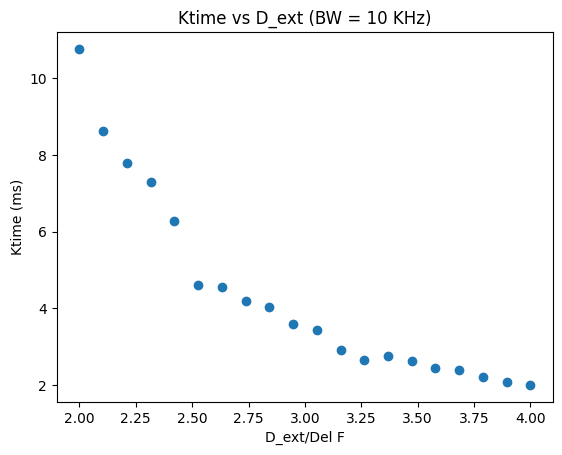

In [19]:
plt.figure()
plt.title("Ktime vs D_ext (BW = 10 KHz)")
plt.xlabel("D_ext/Del F")
plt.ylabel("Ktime (ms)")
kt_mean = [np.mean(kt_D[D]) for D in Dext]
kt_anl = Ktime_anl(vbias, alpha, beta, rho, Dext, tf)
sd = [np.sqrt(2*D*bw*rho)*tf for D in Dext]
plt.plot(Dext/delF, np.array(kt_mean)*1e3, 'o')
# plt.plot(Dext/delF, kt_anl*1e3)

In [1]:
alpha =-6.29e7
beta = 1.09e9
rho = 370
tf = 255e-9
delF = del_U(0, alpha, beta, tf)
print(f"Del F = {delF} V^2 s")

Dext = 2.9*delF # guess value
print(f"Using Dext = {Dext} V^2 s")
# simulation parameters
dt = 100e-9
t = 5e-2
vbias = 0
bw = 1e4
ens = 500

NameError: name 'del_U' is not defined

In [157]:
kt_list = []
print(f"Simulating for D = {Dext} ...")
for e in range(ens+1):
    sd = np.sqrt(2*Dext*bw*rho)*tf
    # print(f"Noise SD = {sd} V")
    stat = False
    kt = 0
    P_in = -0.2
    while(not stat):
        noise = gen_noise(t, sd, bw, dt)
        stat, kt_ens, P_in, _ = sim_ktime(t, noise, P_in, alpha, beta, rho, tf, dt, vbias)
        kt += kt_ens
    kt_list.append(kt)
    # print(f"  Ensemble {e} Ktime: {kt*1e6} us")
    if(e % 100 == 0):
        print(f"Ensemble {e}/{ens} done, kt = {np.mean(kt_list)*1e3} ms")
print(f"Final Ktime = {np.mean(kt_list)*1e3} ms")

Simulating for D = [2631557.11009174] ...
Ensemble 0/500 done, kt = 0.2963 ms
Ensemble 100/500 done, kt = 4.763838613861386 ms
Ensemble 200/500 done, kt = 5.33700248756219 ms
Ensemble 300/500 done, kt = 5.047593355481728 ms
Ensemble 400/500 done, kt = 5.12058029925187 ms
Ensemble 500/500 done, kt = 5.080713972055888 ms
Final Ktime = 5.080713972055888 ms


In [ ]:
from multiprocessing import Pool
import functools

def run_ensemble(e, D, sd, t, bw, dt, alpha, beta, rho, tf, vbias, ens):
    """Helper function to run a single ensemble simulation"""
    stat = False
    kt = 0
    P_in = -0.2
    while not stat:
        noise = gen_noise(t, sd, bw, dt)
        stat, kt_ens, P_in, _ = sim_ktime(t, noise, P_in, alpha, beta, rho, tf, dt, vbias)
        kt += kt_ens
    
    if e % 100 == 0:
        print(f"Ensemble {e}/{ens} done for D={D}")
    return kt

# Parallel execution
kt_D = {}
for D in Dext:
    print(f"Simulating for D = {D} ...")
    sd = np.sqrt(2*D*bw*rho)*tf
    
    # Create a partial function with fixed parameters
    run_func = functools.partial(
        run_ensemble, 
        D=D, sd=sd, t=t, bw=bw, dt=dt, 
        alpha=alpha, beta=beta, rho=rho, tf=tf, vbias=vbias, ens=ens
    )
    
    # Run ensembles in parallel
    with Pool() as pool:
        kt_list = pool.map(run_func, range(ens+1))
    
    kt_D[D] = kt_list
    print(f"D = {D}: kt = {np.mean(kt_list)*1e3} ms")

Simulating for D = 1043668.2692307692 ...
